<a href="https://colab.research.google.com/github/MariamKSharkawy/ML-projects/blob/credit_card_fraud_detection/stock_predict_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/dc[1].csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   object 
 1   open_SAR    1000 non-null   float64
 2   open_USD    1000 non-null   float64
 3   high_SAR    1000 non-null   float64
 4   high_USD    1000 non-null   float64
 5   low_SAR     1000 non-null   float64
 6   low_USD     1000 non-null   float64
 7   close_SAR   1000 non-null   float64
 8   close_USD   1000 non-null   float64
 9   volume      1000 non-null   int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 78.3+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,open_SAR,open_USD,high_SAR,high_USD,low_SAR,low_USD,close_SAR,close_USD,volume
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34825.322255,9285.762120,35789.618165,9542.880270,33796.329057,9011.393200,34917.483572,9310.335850,53100.498000
std,21728.028028,5793.522832,22785.946842,6075.604427,20565.410145,5483.524463,21928.280072,5846.917681,35329.832031
min,12045.197184,3211.710000,12288.185600,3276.500000,11837.237504,3156.260000,12045.234688,3211.720000,5743.000000
25%,24254.558752,6467.192500,24686.089152,6582.255000,23721.336256,6325.015000,24252.946080,6466.762500,30045.750000
50%,30714.632128,8189.695000,31321.953152,8351.630000,30010.869568,8002.045000,30713.263232,8189.330000,43795.500000
75%,38317.311744,10216.860000,39077.527200,10419.562500,37158.878816,9907.977500,38329.725568,10220.170000,64909.250000
max,152217.334784,40586.960000,157329.280000,41950.000000,145215.488000,38720.000000,152201.770624,40582.810000,402201.000000


In [ ]:
df.head()

,Unnamed: 0,open_SAR,open_USD,high_SAR,high_USD,low_SAR,low_USD,close_SAR,close_USD,volume
0,2021-01-30,128437.248512,34246.28,131012.723200,34933.00,123106.880000,32825.00,128333.212416,34218.54,43072
1,2021-01-29,125144.022272,33368.18,144510.037760,38531.90,119695.516160,31915.40,128459.450880,34252.20,231827
2,2021-01-28,113870.357376,30362.19,126703.438592,33783.98,111919.811840,29842.10,125131.570944,33364.86,92621
3,2021-01-27,121753.023104,32464.01,122102.860416,32557.29,109668.146688,29241.72,113885.208960,30366.15,95911
4,2021-01-26,120966.114176,32254.19,123470.218752,32921.88,115652.472448,30837.37,121767.124608,32467.77,84972


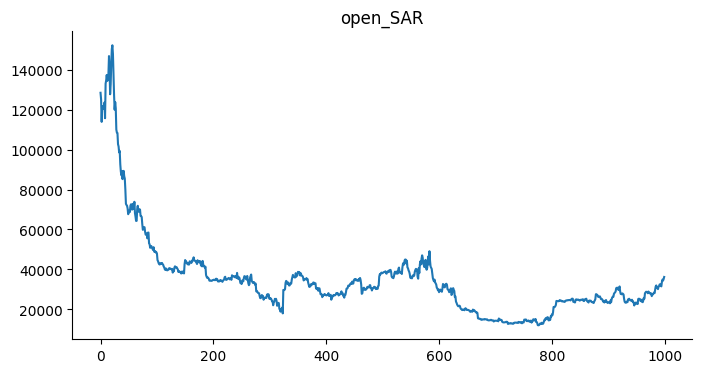

In [ ]:
# @title open_SAR

from matplotlib import pyplot as plt
df['open_SAR'].plot(kind='line', figsize=(8, 4), title='open_SAR')
plt.gca().spines[['top', 'right']].set_visible(False)

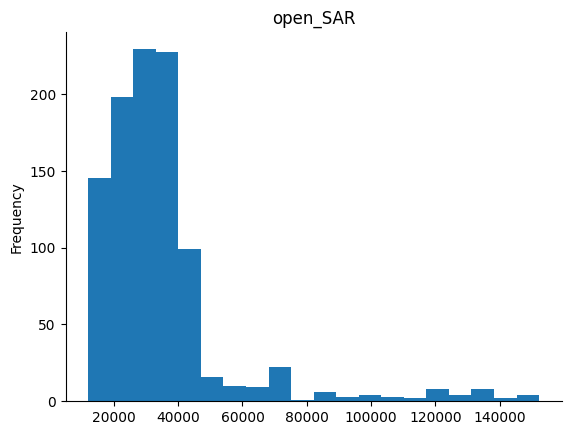

In [ ]:
# @title open_SAR

from matplotlib import pyplot as plt
df['open_SAR'].plot(kind='hist', bins=20, title='open_SAR')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
open_SAR,0
open_USD,0
high_SAR,0
high_USD,0
low_SAR,0
low_USD,0
close_SAR,0
close_USD,0
volume,0


In [ ]:
df.drop(['Unnamed: 0'],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   open_SAR   1000 non-null   float64
 1   open_USD   1000 non-null   float64
 2   high_SAR   1000 non-null   float64
 3   high_USD   1000 non-null   float64
 4   low_SAR    1000 non-null   float64
 5   low_USD    1000 non-null   float64
 6   close_SAR  1000 non-null   float64
 7   close_USD  1000 non-null   float64
 8   volume     1000 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 70.4 KB


In [ ]:
days = 5
sequence = []
target = []

for i in range(days, len(df)):
    sequence.append(df['open_SAR'].values[i-days:i])
    target.append(df['open_SAR'].values[i])

sequence = np.array(sequence)
target = np.array(target)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(sequence, target, test_size=0.4, shuffle=False)

In [ ]:

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from tqdm import tqdm
regressors = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SupportVectorMachine': SVR(kernel='rbf', C=100, gamma='auto', epsilon=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'DecisionTree': DecisionTreeRegressor(random_state=42)
}

model_names = []
evaluation_metrics = []
predicted_outputs = []

for model_name, reg in tqdm(regressors.items(), desc="Training models"):
    reg.fit(x_train, y_train)
    predictions = reg.predict(x_test)
    predicted_outputs.append(predictions)

    metrics = {
        'Model': model_name,
        'MSE': mean_squared_error(y_test, predictions),
        'R2_Score': r2_score(y_test, predictions),
        'MAE': mean_absolute_error(y_test, predictions)
    }

    evaluation_metrics.append(metrics)

results_df = pd.DataFrame(evaluation_metrics)


print("\nModel Performance Comparison:")
print(results_df)


Training models: 100%|██████████| 5/5 [00:00<00:00, 10.17it/s]


Model Performance Comparison:
                  Model           MSE  R2_Score           MAE
0      LinearRegression  5.713390e+05  0.984675    520.124733
1          RandomForest  2.571077e+07  0.310347   3493.859374
2  SupportVectorMachine  2.516658e+08 -5.750556  14641.893304
3                   KNN  2.033438e+07  0.454561   3253.485909
4          DecisionTree  8.443438e+07 -1.264825   6101.363494


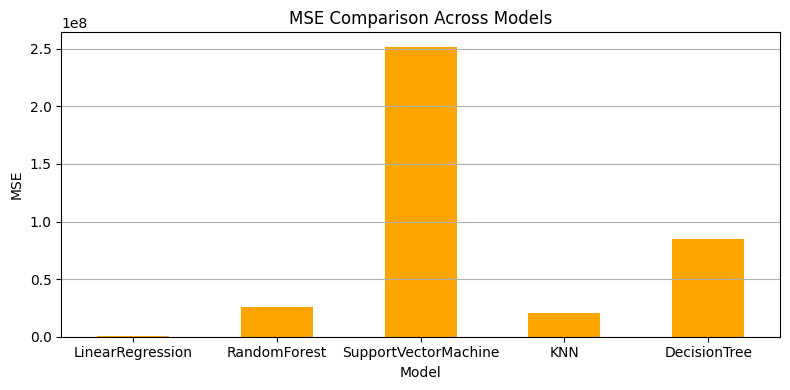

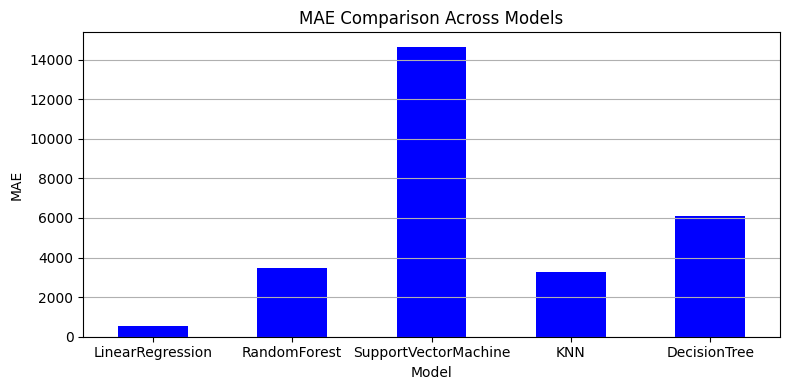

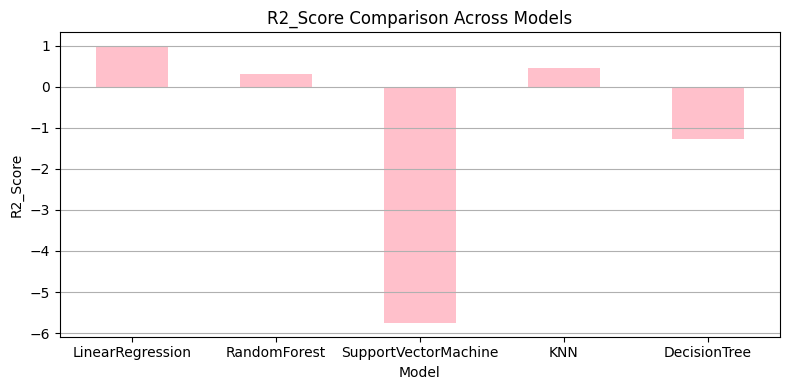

In [ ]:
metrics = ['MSE', 'MAE', 'R2_Score']
colors = ['orange', 'blue', 'pink']  # Plain color names

for metric, color in zip(metrics, colors):
    results_df.set_index('Model')[[metric]].plot(
        kind='bar',
        figsize=(8, 4),
        legend=False,
        color=color
    )
    plt.title(f'{metric} Comparison Across Models')
    plt.ylabel(metric)
    plt.xlabel('Model')
    plt.xticks(rotation=0)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


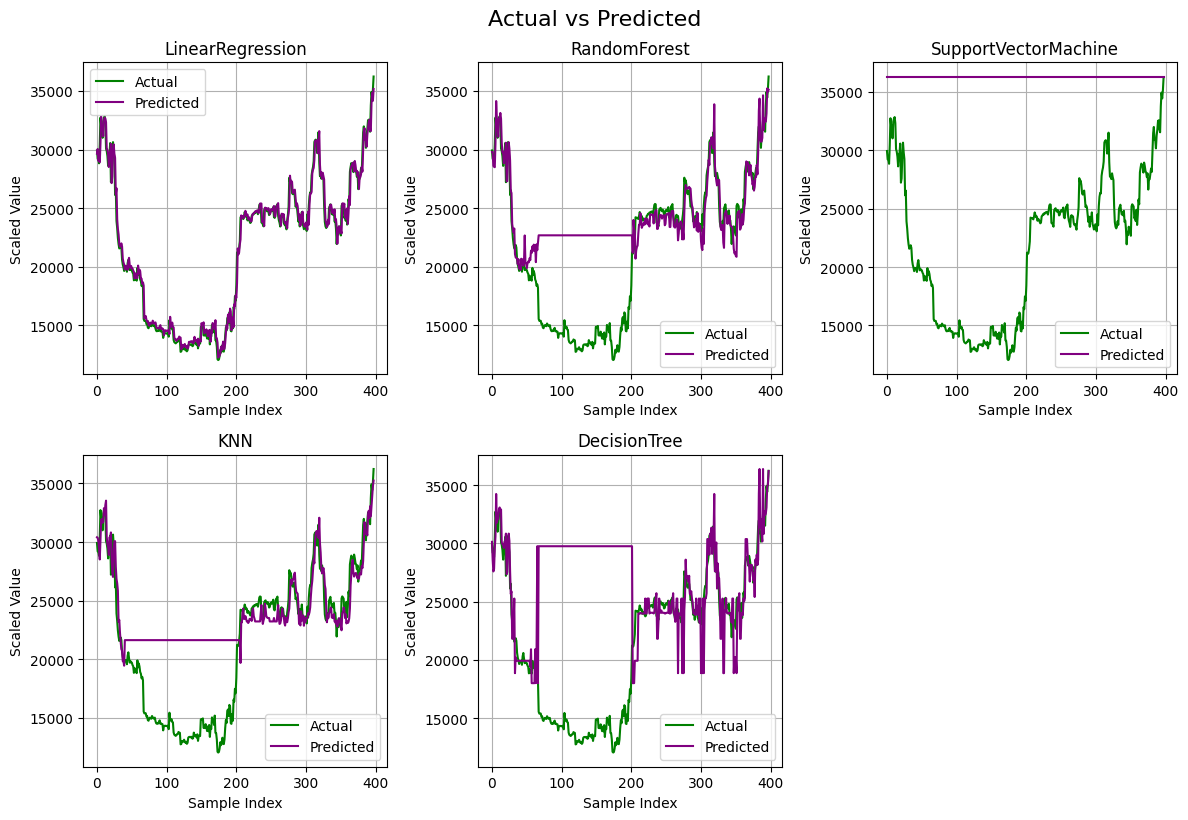

In [ ]:
import matplotlib.pyplot as plt

model_count = len(regressors)
columns = 3
rows = (model_count + 1) // columns

plt.figure(figsize=(12, rows * 4))

for i, (model_label, prediction) in enumerate(zip(regressors.keys(), predicted_outputs)):
    plt.subplot(rows, columns, i + 1)
    plt.plot(y_test, label='Actual', color='green')
    plt.plot(prediction, label='Predicted', color='purple')
    plt.title(f'{model_label}')
    plt.xlabel('Sample Index')
    plt.ylabel('Scaled Value')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle('Actual vs Predicted', fontsize=16, y=1.02)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, LSTM

x_train_rnn = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test_rnn = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))


In [ ]:
model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(x_train_rnn.shape[1], 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(x_train_rnn, y_train, epochs=30, batch_size=16, validation_split=0.2)


Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 2571059200.0000 - mae: 44394.5820 - val_loss: 1471805184.0000 - val_mae: 38116.2695
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2398914560.0000 - mae: 42497.0078 - val_loss: 1471689600.0000 - val_mae: 38114.7539
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2552655872.0000 - mae: 43896.3047 - val_loss: 1471574144.0000 - val_mae: 38113.2383
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2702654976.0000 - mae: 44741.0547 - val_loss: 1471458176.0000 - val_mae: 38111.7266
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2640367104.0000 - mae: 44171.7148 - val_loss: 1471342976.0000 - val_mae: 38110.2070
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2693510656.0000 - mae: 44426.9453 - val_loss: 1471226624.0000 - val_mae: 38108.6836
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2848780288.0000 - mae: 45456.5039 - val_loss: 1471111808.0000 - val_mae: 38107.1758
Epoch

In [ ]:
# Predict
rnn_predictions = model.predict(x_test_rnn)

# Evaluation metrics
rnn_mse = mean_squared_error(y_test, rnn_predictions)
rnn_mae = mean_absolute_error(y_test, rnn_predictions)
rnn_r2 = r2_score(y_test, rnn_predictions)

print(f'RNN - MSE: {rnn_mse}, MAE: {rnn_mae}, R2 Score: {rnn_r2}')


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
RNN - MSE: 504055060.2951151, MAE: 21604.96035441724, R2 Score: -12.520518825654488


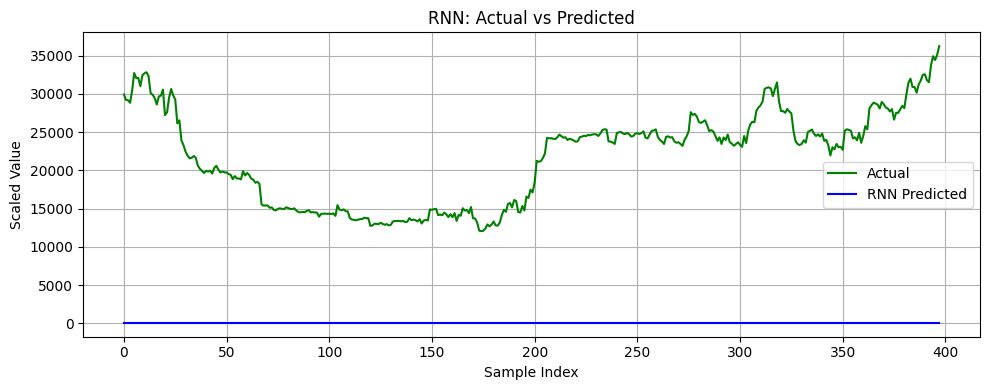

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(y_test, label='Actual', color='green')
plt.plot(rnn_predictions, label='RNN Predicted', color='blue')
plt.title('RNN: Actual vs Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(x_train_rnn.shape[1], 1)),
    Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0470 - mae: 0.1434 - val_loss: 0.0054 - val_mae: 0.0707
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0055 - mae: 0.0625 - val_loss: 3.2859e-04 - val_mae: 0.0148
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.8190e-04 - mae: 0.0179 - val_loss: 3.1596e-04 - val_mae: 0.0143
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.2305e-04 - mae: 0.0168 - val_loss: 3.1549e-04 - val_mae: 0.0143
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.1844e-04 - mae: 0.0153 - val_loss: 3.7507e-04 - val_mae: 0.0153
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.4780e-04 - mae: 0.0164 - val_loss: 3.1599e-04 - val_mae: 0.0142
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.8488e-04 - mae: 0.0159 - val_loss: 3.2347e-04 - val_mae: 0.0143
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.4690e-04 - mae: 0.0139 - val_loss: 4.4223e-04 - val_mae: 0.0165
Epoch 9/30
30/30 ━━━━━━━━━━━━━

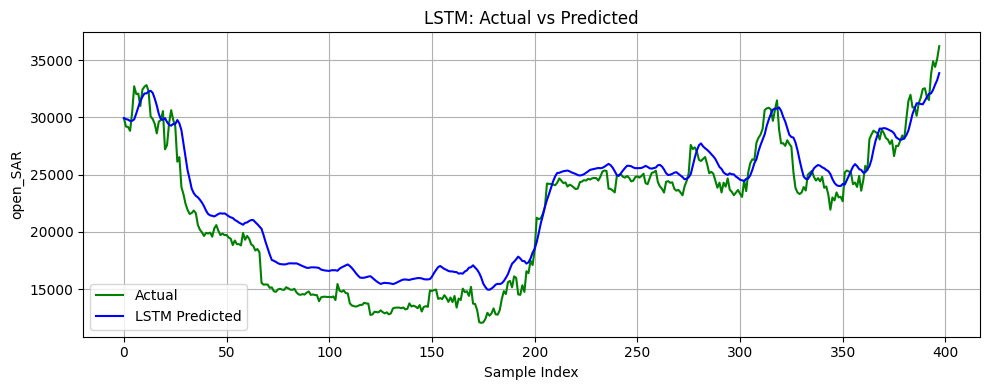

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load the dataset
df = pd.read_csv('/content/dc[1].csv')
df.drop(['Unnamed: 0'], axis=1, inplace=True)

# Scale the open_SAR column
scaler = MinMaxScaler()
df['open_SAR_scaled'] = scaler.fit_transform(df[['open_SAR']])

# Sequence creation
days = 5
sequence = []
target = []

for i in range(days, len(df)):
    sequence.append(df['open_SAR_scaled'].values[i-days:i])
    target.append(df['open_SAR_scaled'].values[i])

sequence = np.array(sequence)
target = np.array(target)

# Train-test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(sequence, target, test_size=0.4, shuffle=False)

# Reshape for LSTM: (samples, timesteps, features)
x_train_rnn = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test_rnn = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

# LSTM model
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(x_train_rnn.shape[1], 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(x_train_rnn, y_train, epochs=30, batch_size=16, validation_split=0.2)

# Predict
rnn_predictions_scaled = model.predict(x_test_rnn)

# Inverse transform predictions and actuals
rnn_predictions = scaler.inverse_transform(rnn_predictions_scaled)
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluation
mse = mean_squared_error(y_test_original, rnn_predictions)
mae = mean_absolute_error(y_test_original, rnn_predictions)
r2 = r2_score(y_test_original, rnn_predictions)

print(f"LSTM - MSE: {mse:.4f}, MAE: {mae:.4f}, R2 Score: {r2:.4f}")

# Plot results
plt.figure(figsize=(10, 4))
plt.plot(y_test_original, label='Actual', color='green')
plt.plot(rnn_predictions, label='LSTM Predicted', color='blue')
plt.title('LSTM: Actual vs Predicted')
plt.xlabel('Sample Index')
plt.ylabel('open_SAR')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
